<a href="https://colab.research.google.com/github/Anika536/python-for-defensive-security/blob/main/DDoS_testcase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# Imports
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             precision_score, roc_auc_score)
from imblearn.over_sampling import ADASYN
from collections import Counter
from statistics import stdev

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Conv1D, MaxPooling1D, LSTM, GRU,
                                     Flatten, Dropout, SimpleRNN)

from sklearn.ensemble import StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

# ================================
# Load dataset
# ================================
df_train = '/content/drive/MyDrive/Labdataset.csv'
train_data = pd.read_csv(df_train)

# Drop useless column if present
if "Unnamed: 15" in train_data.columns:
    train_data = train_data.drop(columns=["Unnamed: 15"])

# ================================
# Handle Missing Values
# ================================
# Fill categorical NaNs with "Unknown"
categorical_cols = ['Source','Destination Address','Target Address','Protocol',
                    'Type','Next Header','Info']
for col in categorical_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna("Unknown")

# Fill numeric NaNs with median
numeric_cols = ['Time','Length','Code','Length_1','Hop Limit',
                'Payload Length','Frame Number']
for col in numeric_cols:
    if col in train_data.columns:
        train_data[col] = train_data[col].fillna(train_data[col].median())

# ================================
# Encode categorical columns
# ================================
le = LabelEncoder()
for col in categorical_cols:
    if col in train_data.columns:
        train_data[col] = le.fit_transform(train_data[col])

print(train_data.info())
print("Missing values per column:\n", train_data.isnull().sum())

# ================================
# Features and Labels
# ================================
Y = train_data['Class']
Y_i = Y.map({'Normal': 0, 'Attack': 1})
X = train_data.drop(columns=['Class'])

print("Shapes:", X.shape, Y_i.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y_i, test_size=0.2, random_state=12, stratify=Y_i
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# ================================
# Balance with ADASYN
# ================================
ada = ADASYN(sampling_strategy='minority', random_state=12)
X_res, Y_res = ada.fit_resample(X_train, y_train)
print('After ADASYN:', Counter(Y_res))

# ================================
# Scale data
# ================================
scaler = MinMaxScaler()
X_train_enc = scaler.fit_transform(X_res)
X_test_enc = scaler.transform(X_test)

# Reshape for CNN/RNN
X_train_enc = np.expand_dims(X_train_enc, axis=2)
X_test_enc = np.expand_dims(X_test_enc, axis=2)

print("Reshaped:", X_train_enc.shape, X_test_enc.shape)

# ================================
# CNN + LSTM Model
# ================================
cnn_model = Sequential()
cnn_model.add(Conv1D(64, 2, input_shape=(X_train_enc.shape[1], 1)))
cnn_model.add(LSTM(100, return_sequences=True))
cnn_model.add(MaxPooling1D(1))
cnn_model.add(Conv1D(32, 2))
cnn_model.add(MaxPooling1D(1))
cnn_model.add(Flatten())
cnn_model.add(Dense(32, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(16, activation='relu'))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

cnn_model.fit(
    X_train_enc, Y_res,
    validation_data=(X_test_enc, y_test),
    epochs=5,
    batch_size=128,
    verbose=1,
    callbacks=[
        ModelCheckpoint('./CNN_LSTM.h5', save_best_only=True, monitor='val_loss'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
    ]
)

y_pred_cnn = (cnn_model.predict(X_test_enc) > 0.5).astype("int32")

# ================================
# RNN + GRU Model
# ================================
rnn_model = Sequential()
rnn_model.add(SimpleRNN(128, activation='relu', return_sequences=True, input_shape=(X_train_enc.shape[1],1)))
rnn_model.add(GRU(64, return_sequences=False))
rnn_model.add(Dense(64, activation='relu'))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(32, activation='relu'))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

rnn_model.fit(
    X_train_enc, Y_res,
    validation_data=(X_test_enc, y_test),
    epochs=5,
    batch_size=128,
    verbose=1,
    callbacks=[
        ModelCheckpoint('./RNN_GRU.h5', save_best_only=True, monitor='val_loss'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)
    ]
)

y_pred_rnn = (rnn_model.predict(X_test_enc) > 0.5).astype("int32")

# ================================
# Stacking Classifier
# ================================
stack_model = StackingClassifier(
    estimators=[('mlp', MLPClassifier(max_iter=500))],
    final_estimator=LogisticRegression(),
    cv=3
)

stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

# ================================
# Metrics Function
# ================================
def get_scores(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_pred)
    }

# ================================
# Collect Results
# ================================
results = []
results.append(get_scores(y_test, y_pred_cnn, "CNN-LSTM"))
results.append(get_scores(y_test, y_pred_rnn, "RNN-GRU"))
results.append(get_scores(y_test, y_pred_stack, "Stacking"))

results_df = pd.DataFrame(results)
print("\n📊 Final Model Comparison:")
print(results_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Time                 1048575 non-null  float64
 1   Source               1048575 non-null  int64  
 2   Destination Address  1048575 non-null  int64  
 3   Target Address       1048575 non-null  int64  
 4   Protocol             1048575 non-null  int64  
 5   Length               1048575 non-null  int64  
 6   Type                 1048575 non-null  int64  
 7   Code                 1048575 non-null  float64
 8   Length_1             1048575 non-null  float64
 9   Hop Limit            1048575 non-null  float64
 10  Payload Length       1048575 non-null  float64
 11  Next Header          1048575 non-null  int64  
 12  Frame Number         1048575 non-null  int64  
 13  Info                 1048575 non-null  int64  
 14  Class                1048575 non-null  object 
dty

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 104s 8ms/step - accuracy: 0.9912 - loss: 0.0200 - val_accuracy: 1.0000 - val_loss: 3.8839e-04 - learning_rate: 0.0010
Epoch 2/5
13068/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.1732e-04

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 98s 8ms/step - accuracy: 1.0000 - loss: 2.1731e-04 - val_accuracy: 1.0000 - val_loss: 3.8087e-04 - learning_rate: 0.0010
Epoch 3/5
13064/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.1779e-05

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 98s 7ms/step - accuracy: 1.0000 - loss: 5.1817e-05 - val_accuracy: 1.0000 - val_loss: 1.5007e-04 - learning_rate: 0.0010
Epoch 4/5
13066/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.8232e-05

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 100s 8ms/step - accuracy: 1.0000 - loss: 5.8225e-05 - val_accuracy: 1.0000 - val_loss: 1.3941e-04 - learning_rate: 0.0010
Epoch 5/5
13070/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 2.5642e-04

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 98s 8ms/step - accuracy: 1.0000 - loss: 2.5639e-04 - val_accuracy: 1.0000 - val_loss: 1.7684e-06 - learning_rate: 0.0010
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
Epoch 1/5
13071/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9935 - loss: 0.0168

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 262s 20ms/step - accuracy: 0.9935 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 3.1949e-04 - learning_rate: 0.0010
Epoch 2/5
13071/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9998 - loss: 0.0013

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 253s 19ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.9322e-04 - learning_rate: 0.0010
Epoch 3/5
13071/13071 ━━━━━━━━━━━━━━━━━━━━ 261s 20ms/step - accuracy: 0.9998 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 2.9419e-04 - learning_rate: 0.0010
Epoch 4/5
13071/13071 ━━━━━━━━━━━━━━━━━━━━ 256s 20ms/step - accuracy: 0.9999 - loss: 8.2267e-04 - val_accuracy: 1.0000 - val_loss: 3.7237e-04 - learning_rate: 0.0010
Epoch 5/5
13069/13071 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 4.0625e-05

13071/13071 ━━━━━━━━━━━━━━━━━━━━ 261s 20ms/step - accuracy: 1.0000 - loss: 4.0621e-05 - val_accuracy: 1.0000 - val_loss: 2.0355e-07 - learning_rate: 1.0000e-04
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step

📊 Final Model Comparison:
      Model  Accuracy    Recall  Precision  F1 Score   ROC AUC
0  CNN-LSTM  1.000000  1.000000   1.000000  1.000000  1.000000
1   RNN-GRU  1.000000  1.000000   1.000000  1.000000  1.000000
2  Stacking  0.934678  0.934575   0.999913  0.966141  0.952881


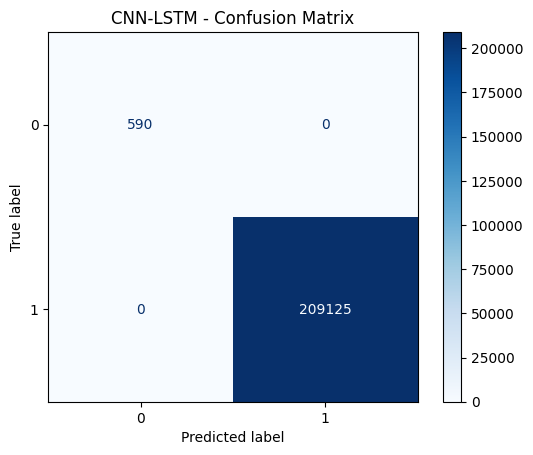

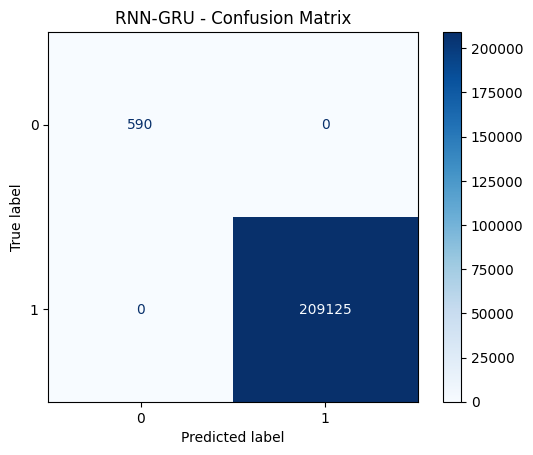

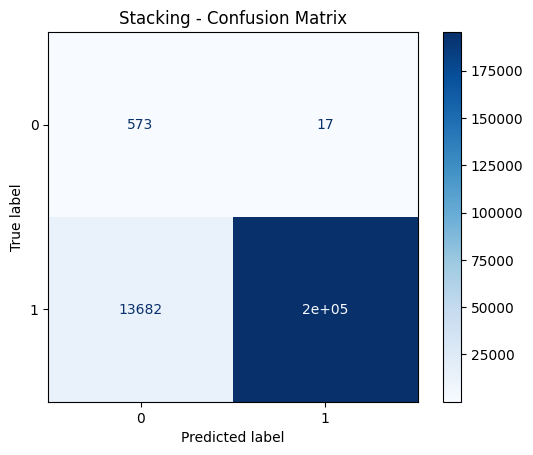

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step


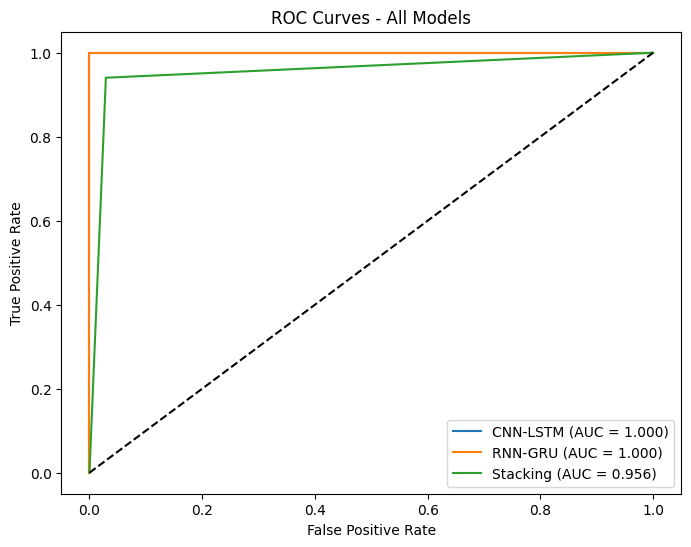

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ================================
# Confusion Matrices
# ================================
models_preds = {
    "CNN-LSTM": y_pred_cnn,
    "RNN-GRU": y_pred_rnn,
    "Stacking": y_pred_stack
}

for name, y_pred in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# ================================
# ROC Curves
# ================================
plt.figure(figsize=(8,6))

# CNN-LSTM
y_prob_cnn = cnn_model.predict(X_test_enc).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob_cnn)
auc_score = roc_auc_score(y_test, y_prob_cnn)
plt.plot(fpr, tpr, label=f"CNN-LSTM (AUC = {auc_score:.3f})")

# RNN-GRU
y_prob_rnn = rnn_model.predict(X_test_enc).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob_rnn)
auc_score = roc_auc_score(y_test, y_prob_rnn)
plt.plot(fpr, tpr, label=f"RNN-GRU (AUC = {auc_score:.3f})")

# Stacking Classifier
y_prob_stack = stack_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_stack)
auc_score = roc_auc_score(y_test, y_prob_stack)
plt.plot(fpr, tpr, label=f"Stacking (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.show()
